``` text
Download log
→ Load raw 10-K files
→ Convert HTML to clean text
→ Measure document size
→ Count keywords
→ Create simple charts
→ Save clean filing text


# 02 Data Understanding and EDA

## Goal

This notebook explores the SEC 10-K filings downloaded in the previous notebook.

Before building a RAG system, we need to understand the data:

- Which companies were downloaded?
- How large are the filings?
- What filing dates are included?
- How much readable text exists?
- Which risk-related keywords appear most often?
- Are the raw documents ready for section extraction and chunking?

This notebook turns raw SEC HTML filings into clean text and creates basic EDA summaries.

In [2]:
# Import tools for working with files and folders
from pathlib import Path

# Import pandas for tabular data analysis
import pandas as pd

# Import matplotlib for simple charts
import matplotlib.pyplot as plt
import seaborn as sns

# Import BeautifulSoup to parse SEC HTML filings
from bs4 import BeautifulSoup

# Import regular expressions for text cleaning
import re

In [3]:
# Detect the project root automatically
# If the notebook is inside the notebooks folder, move one level up
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

# Create main project folders
DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

# Create SEC-specific folders
SEC_RAW_DIR = RAW_DIR / "sec_filings"
SEC_METADATA_DIR = RAW_DIR / "sec_metadata"

# Create output folder for cleaned text
CLEAN_TEXT_DIR = PROCESSED_DIR / "clean_sec_text"
CLEAN_TEXT_DIR.mkdir(parents=True, exist_ok=True)

# Print paths to verify the notebook is pointing to the right folders
print("Project root:", PROJECT_ROOT)
print("SEC raw filing folder:", SEC_RAW_DIR)
print("SEC metadata folder:", SEC_METADATA_DIR)
print("Clean text output folder:", CLEAN_TEXT_DIR)

Project root: c:\Users\tevin\OneDrive\Desktop\LLM-And-Generative-AI\rag\RiskRadar-AI
SEC raw filing folder: c:\Users\tevin\OneDrive\Desktop\LLM-And-Generative-AI\rag\RiskRadar-AI\data\raw\sec_filings
SEC metadata folder: c:\Users\tevin\OneDrive\Desktop\LLM-And-Generative-AI\rag\RiskRadar-AI\data\raw\sec_metadata
Clean text output folder: c:\Users\tevin\OneDrive\Desktop\LLM-And-Generative-AI\rag\RiskRadar-AI\data\processed\clean_sec_text


In [4]:
# Set path to the download log from notebook 01
download_log_file = SEC_METADATA_DIR / "starter_company_10k_download_log.csv"

# Check that the file exists before loading it
if not download_log_file.exists():
    raise FileNotFoundError(
        f"Could not find {download_log_file}. Run 01_data_ingestion_sec_filings.ipynb first."
    )

# Load the download log
download_log = pd.read_csv(download_log_file)

# Preview the downloaded filing records
download_log

,ticker,company_name,filing_date,accession_number,filing_url,local_file,character_count
0,AAPL,Apple,2025-10-31,0000320193-25-000079,https://www.sec.gov/Archives/edgar/data/320193...,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...,1520208
1,AMD,Advanced Micro Devices,2026-02-04,0000002488-26-000018,https://www.sec.gov/Archives/edgar/data/2488/0...,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...,2174592
2,MSFT,Microsoft,2025-07-30,0000950170-25-100235,https://www.sec.gov/Archives/edgar/data/789019...,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...,8158067
3,NVDA,NVIDIA,2026-02-25,0001045810-26-000021,https://www.sec.gov/Archives/edgar/data/104581...,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...,1967816
4,TSLA,Tesla,2026-01-29,0001628280-26-003952,https://www.sec.gov/Archives/edgar/data/131860...,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...,2391529


In [5]:
# Count how many filings were downloaded
num_filings = len(download_log)

# Count how many unique companies are included
num_companies = download_log["ticker"].nunique()

# Find the earliest and latest filing dates
earliest_date = download_log["filing_date"].min()
latest_date = download_log["filing_date"].max()

# Print a simple summary
print("Number of downloaded filings:", num_filings)
print("Number of unique companies:", num_companies)
print("Earliest filing date:", earliest_date)
print("Latest filing date:", latest_date)

Number of downloaded filings: 5
Number of unique companies: 5
Earliest filing date: 2025-07-30
Latest filing date: 2026-02-25


In [6]:
# Create a clean metadata view for EDA
filing_metadata = download_log[
    [
        "ticker",
        "company_name",
        "filing_date",
        "accession_number",
        "character_count",
        "local_file"
    ]
].copy()

# Sort by ticker for readability
filing_metadata = filing_metadata.sort_values("ticker").reset_index(drop=True)

# Display the metadata table
filing_metadata

,ticker,company_name,filing_date,accession_number,character_count,local_file
0,AAPL,Apple,2025-10-31,0000320193-25-000079,1520208,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...
1,AMD,Advanced Micro Devices,2026-02-04,0000002488-26-000018,2174592,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...
2,MSFT,Microsoft,2025-07-30,0000950170-25-100235,8158067,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...
3,NVDA,NVIDIA,2026-02-25,0001045810-26-000021,1967816,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...
4,TSLA,Tesla,2026-01-29,0001628280-26-003952,2391529,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...


Chart: Raw Filing Size by Company

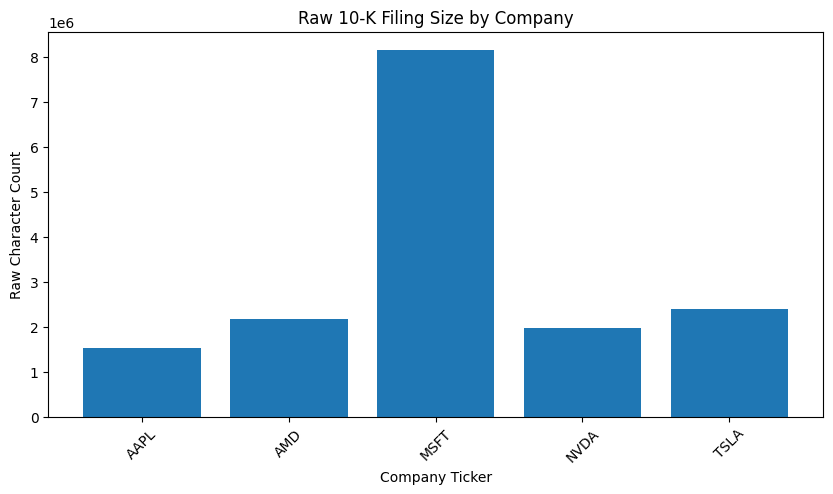

In [7]:
# Create a bar chart showing raw filing character count by company
plt.figure(figsize=(10, 5))

# Plot character count by ticker
plt.bar(filing_metadata["ticker"], filing_metadata["character_count"])

# Add chart title and labels
plt.title("Raw 10-K Filing Size by Company")
plt.xlabel("Company Ticker")
plt.ylabel("Raw Character Count")

# Rotate x-axis labels if needed
plt.xticks(rotation=45)

# Display the chart
plt.show()

In [8]:
def clean_html_to_text(html):
    """
    Convert raw SEC HTML filing text into readable plain text.
    """

    # Parse HTML using BeautifulSoup
    soup = BeautifulSoup(html, "lxml")

    # Remove script and style elements because they are not useful filing text
    for tag in soup(["script", "style"]):
        tag.decompose()

    # Extract visible text from the HTML
    text = soup.get_text(separator=" ", strip=True)

    # Replace repeated whitespace with a single space
    text = re.sub(r"\s+", " ", text)

    # Remove leading and trailing spaces
    text = text.strip()

    # Return cleaned text
    return text

Clean All Downloaded Filings

In [9]:
# Create an empty list to store clean filing records
clean_records = []

# Loop through each downloaded filing
for _, row in download_log.iterrows():

    # Get the local file path from the download log
    file_path = Path(row["local_file"])

    # Read the raw SEC filing HTML
    raw_html = file_path.read_text(encoding="utf-8")

    # Convert raw HTML into clean readable text
    clean_text = clean_html_to_text(raw_html)

    # Create clean text file name
    clean_file_name = f"{row['ticker']}_{row['filing_date']}_10K_clean.txt"

    # Create full output path
    clean_file_path = CLEAN_TEXT_DIR / clean_file_name

    # Save clean text locally
    clean_file_path.write_text(clean_text, encoding="utf-8")

    # Store metadata about the cleaned filing
    clean_records.append({
        "ticker": row["ticker"],
        "company_name": row["company_name"],
        "filing_date": row["filing_date"],
        "accession_number": row["accession_number"],
        "raw_character_count": row["character_count"],
        "clean_character_count": len(clean_text),
        "clean_word_count": len(clean_text.split()),
        "raw_file": str(file_path),
        "clean_file": str(clean_file_path)
    })

# Convert records into a DataFrame
clean_filings_df = pd.DataFrame(clean_records)

# Display the cleaned filing summary
clean_filings_df

C:\Users\tevin\AppData\Local\Temp\ipykernel_7812\795300028.py:7: XMLParsedAsHTMLWarning: It looks like you're using an HTML parser to parse an XML document.

Assuming this really is an XML document, what you're doing might work, but you should know that using an XML parser will be more reliable. To parse this document as XML, make sure you have the Python package 'lxml' installed, and pass the keyword argument `features="xml"` into the BeautifulSoup constructor.

If you want or need to use an HTML parser on this document, you can make this warning go away by filtering it. To do that, run this code before calling the BeautifulSoup constructor:

    from bs4 import XMLParsedAsHTMLWarning
    import warnings

    warnings.filterwarnings("ignore", category=XMLParsedAsHTMLWarning)

  soup = BeautifulSoup(html, "lxml")


,ticker,company_name,filing_date,accession_number,raw_character_count,clean_character_count,clean_word_count,raw_file,clean_file
0,AAPL,Apple,2025-10-31,0000320193-25-000079,1520208,220566,32213,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...
1,AMD,Advanced Micro Devices,2026-02-04,0000002488-26-000018,2174592,425188,61758,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...
2,MSFT,Microsoft,2025-07-30,0000950170-25-100235,8158067,347391,49356,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...
3,NVDA,NVIDIA,2026-02-25,0001045810-26-000021,1967816,360422,53068,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...
4,TSLA,Tesla,2026-01-29,0001628280-26-003952,2391529,429673,62155,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...


In [10]:
# Set output path for cleaned filing metadata
clean_metadata_file = PROCESSED_DIR / "clean_sec_filing_metadata.csv"

# Save cleaned filing metadata
clean_filings_df.to_csv(clean_metadata_file, index=False)

# Confirm the file was saved
print("Saved clean filing metadata to:", clean_metadata_file)

Saved clean filing metadata to: c:\Users\tevin\OneDrive\Desktop\LLM-And-Generative-AI\rag\RiskRadar-AI\data\processed\clean_sec_filing_metadata.csv


In [11]:
# Create a comparison table for raw and clean text size
size_comparison = clean_filings_df[
    [
        "ticker",
        "raw_character_count",
        "clean_character_count",
        "clean_word_count"
    ]
].copy()

# Calculate how much text remains after HTML cleaning
size_comparison["clean_to_raw_ratio"] = (
    size_comparison["clean_character_count"] / size_comparison["raw_character_count"]
)

# Display the comparison table
size_comparison

,ticker,raw_character_count,clean_character_count,clean_word_count,clean_to_raw_ratio
0,AAPL,1520208,220566,32213,0.145089
1,AMD,2174592,425188,61758,0.195525
2,MSFT,8158067,347391,49356,0.042583
3,NVDA,1967816,360422,53068,0.183158
4,TSLA,2391529,429673,62155,0.179665


#### Chart: Clean Word Count by Company

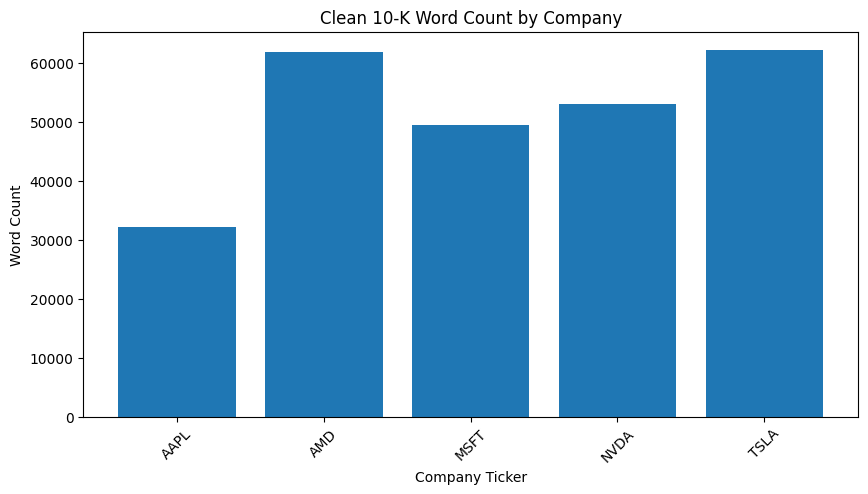

In [12]:
# Create a bar chart showing clean word count by company
plt.figure(figsize=(10, 5))

# Plot clean word count by ticker
plt.bar(clean_filings_df["ticker"], clean_filings_df["clean_word_count"])

# Add title and labels
plt.title("Clean 10-K Word Count by Company")
plt.xlabel("Company Ticker")
plt.ylabel("Word Count")

# Rotate labels for readability
plt.xticks(rotation=45)

# Display the chart
plt.show()

In [13]:
# Select the first clean filing
sample_clean_file = Path(clean_filings_df.iloc[0]["clean_file"])

# Read clean text from disk
sample_clean_text = sample_clean_file.read_text(encoding="utf-8")

# Print file name and text length
print("File:", sample_clean_file.name)
print("Character count:", len(sample_clean_text))
print("Word count:", len(sample_clean_text.split()))

# Preview the first 2,000 characters
print(sample_clean_text[:2000])

File: AAPL_2025-10-31_10K_clean.txt
Character count: 220566
Word count: 32213
aapl-20250927 false 2025 FY 0000320193 P1Y P1Y P1Y P1Y http://fasb.org/us-gaap/2025#LongTermDebtNoncurrent http://fasb.org/us-gaap/2025#LongTermDebtNoncurrent http://fasb.org/us-gaap/2025#OtherAssetsNoncurrent http://fasb.org/us-gaap/2025#OtherAssetsNoncurrent http://fasb.org/us-gaap/2025#PropertyPlantAndEquipmentNet http://fasb.org/us-gaap/2025#PropertyPlantAndEquipmentNet http://fasb.org/us-gaap/2025#OtherLiabilitiesCurrent http://fasb.org/us-gaap/2025#OtherLiabilitiesCurrent http://fasb.org/us-gaap/2025#OtherLiabilitiesNoncurrent http://fasb.org/us-gaap/2025#OtherLiabilitiesNoncurrent http://fasb.org/us-gaap/2025#OtherLiabilitiesCurrent http://fasb.org/us-gaap/2025#OtherLiabilitiesCurrent http://fasb.org/us-gaap/2025#OtherLiabilitiesNoncurrent http://fasb.org/us-gaap/2025#OtherLiabilitiesNoncurrent iso4217:USD xbrli:shares iso4217:USD xbrli:shares xbrli:pure aapl:Customer aapl:Vendor aapl:Subsidiary 000032

In [14]:
# Create a list of keywords that often appear in risk and business sections
risk_keywords = [
    "risk",
    "competition",
    "competitive",
    "regulation",
    "regulatory",
    "litigation",
    "supply chain",
    "cybersecurity",
    "inflation",
    "interest rates",
    "artificial intelligence",
    "AI",
    "privacy",
    "data security",
    "macroeconomic",
    "geopolitical",
    "tariff",
    "semiconductor",
    "cloud",
    "revenue",
    "margin"
]

# Display the keyword list
risk_keywords

['risk',
 'competition',
 'competitive',
 'regulation',
 'regulatory',
 'litigation',
 'supply chain',
 'cybersecurity',
 'inflation',
 'interest rates',
 'artificial intelligence',
 'AI',
 'privacy',
 'data security',
 'macroeconomic',
 'geopolitical',
 'tariff',
 'semiconductor',
 'cloud',
 'revenue',
 'margin']

In [15]:
def count_keywords(text, keywords):
    """
    Count how many times each keyword appears in a text.
    """

    # Convert text to lowercase so matching is case-insensitive
    text_lower = text.lower()

    # Create an empty dictionary for keyword counts
    keyword_counts = {}

    # Loop through each keyword
    for keyword in keywords:

        # Convert keyword to lowercase
        keyword_lower = keyword.lower()

        # Count exact keyword occurrences
        count = text_lower.count(keyword_lower)

        # Store the count
        keyword_counts[keyword] = count

    # Return the keyword count dictionary
    return keyword_counts

In [16]:
# Create an empty list to store keyword count records
keyword_records = []

# Loop through each clean filing
for _, row in clean_filings_df.iterrows():

    # Read clean filing text
    clean_text = Path(row["clean_file"]).read_text(encoding="utf-8")

    # Count risk keywords
    counts = count_keywords(clean_text, risk_keywords)

    # Add metadata to the keyword count record
    counts["ticker"] = row["ticker"]
    counts["company_name"] = row["company_name"]
    counts["filing_date"] = row["filing_date"]

    # Store the record
    keyword_records.append(counts)

# Convert keyword records into a DataFrame
keyword_counts_df = pd.DataFrame(keyword_records)

# Move metadata columns to the front
metadata_cols = ["ticker", "company_name", "filing_date"]
keyword_cols = [col for col in keyword_counts_df.columns if col not in metadata_cols]

keyword_counts_df = keyword_counts_df[metadata_cols + keyword_cols]

# Display keyword counts
keyword_counts_df

,ticker,company_name,filing_date,risk,competition,competitive,regulation,regulatory,litigation,supply chain,...,AI,privacy,data security,macroeconomic,geopolitical,tariff,semiconductor,cloud,revenue,margin
0,AAPL,Apple,2025-10-31,97,20,18,24,16,18,10,...,444,8,4,8,4,22,7,4,27,35
1,AMD,Advanced Micro Devices,2026-02-04,136,14,37,66,18,26,19,...,1163,6,2,5,2,13,36,24,119,17
2,MSFT,Microsoft,2025-07-30,95,23,26,39,32,4,12,...,835,11,3,1,10,5,0,237,249,24
3,NVDA,NVIDIA,2026-02-25,113,17,30,48,34,29,25,...,890,29,0,5,11,14,20,27,172,16
4,TSLA,Tesla,2026-01-29,101,12,21,56,70,18,20,...,1097,17,0,5,2,27,2,0,207,14


#### Save Keyword Counts

In [17]:
# Set output path for keyword counts
keyword_counts_file = PROCESSED_DIR / "sec_10k_keyword_counts.csv"

# Save keyword counts to CSV
keyword_counts_df.to_csv(keyword_counts_file, index=False)

# Confirm the file was saved
print("Saved keyword counts to:", keyword_counts_file)

Saved keyword counts to: c:\Users\tevin\OneDrive\Desktop\LLM-And-Generative-AI\rag\RiskRadar-AI\data\processed\sec_10k_keyword_counts.csv


#### Total Keyword Counts

In [18]:
# Sum keyword counts across all companies
total_keyword_counts = (
    keyword_counts_df[keyword_cols]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# Rename columns for readability
total_keyword_counts.columns = ["keyword", "total_count"]

# Display total keyword counts
total_keyword_counts

,keyword,total_count
0,AI,4429
1,revenue,774
2,risk,542
3,cloud,292
4,regulation,233
5,regulatory,170
6,cybersecurity,156
7,competitive,132
8,margin,106
9,litigation,95


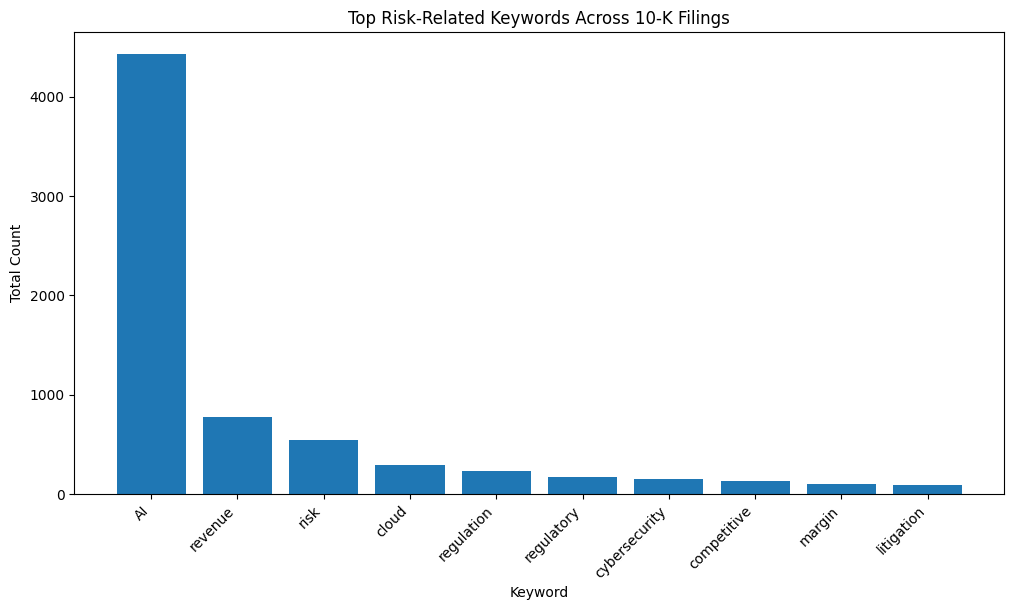

In [20]:
# Select the top 10 most frequent keywords
top_keywords = total_keyword_counts.head(10)

# Create a bar chart for top keyword counts
plt.figure(figsize=(12, 6))

# Plot keyword counts
plt.bar(top_keywords["keyword"], top_keywords["total_count"])

# Add title and labels
plt.title("Top Risk-Related Keywords Across 10-K Filings")
plt.xlabel("Keyword")
plt.ylabel("Total Count")

# Rotate labels for readability
plt.xticks(rotation=45, ha="right")

# Display chart
plt.show()

In [21]:
# Select AI-related keyword columns that exist in the DataFrame
ai_columns = ["artificial intelligence", "AI"]

# Create AI mention comparison table
ai_mentions = keyword_counts_df[
    ["ticker", "company_name", "filing_date"] + ai_columns
].copy()

# Add total AI mentions
ai_mentions["total_ai_mentions"] = ai_mentions[ai_columns].sum(axis=1)

# Sort by total AI mentions
ai_mentions = ai_mentions.sort_values("total_ai_mentions", ascending=False)

# Display AI mentions
ai_mentions

,ticker,company_name,filing_date,artificial intelligence,AI,total_ai_mentions
1,AMD,Advanced Micro Devices,2026-02-04,2,1163,1165
4,TSLA,Tesla,2026-01-29,12,1097,1109
3,NVDA,NVIDIA,2026-02-25,2,890,892
2,MSFT,Microsoft,2025-07-30,3,835,838
0,AAPL,Apple,2025-10-31,6,444,450


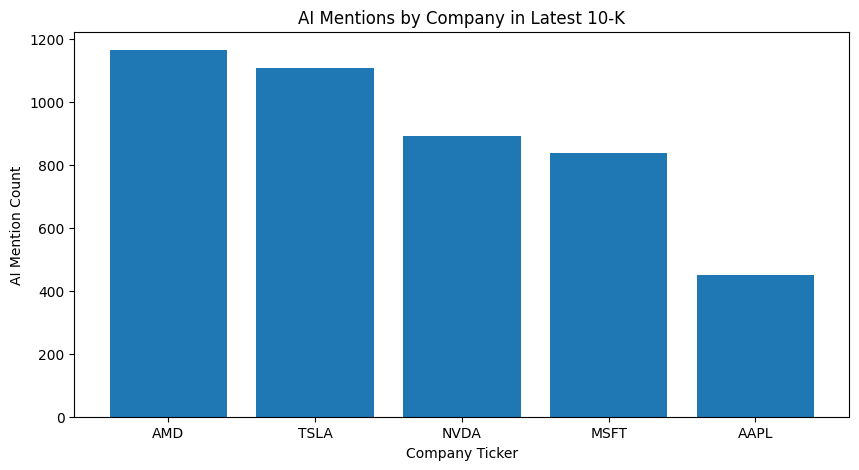

In [22]:
# Create a bar chart showing AI mentions by company
plt.figure(figsize=(10, 5))

# Plot total AI mentions
plt.bar(ai_mentions["ticker"], ai_mentions["total_ai_mentions"])

# Add title and labels
plt.title("AI Mentions by Company in Latest 10-K")
plt.xlabel("Company Ticker")
plt.ylabel("AI Mention Count")

# Display chart
plt.show()

In [23]:
# Convert keyword counts from wide format to long format
keyword_long_df = keyword_counts_df.melt(
    id_vars=["ticker", "company_name", "filing_date"],
    value_vars=keyword_cols,
    var_name="keyword",
    value_name="count"
)

# Sort by company and count
keyword_long_df = keyword_long_df.sort_values(
    ["ticker", "count"],
    ascending=[True, False]
).reset_index(drop=True)

# Display long-format keyword table
keyword_long_df.head(30)

,ticker,company_name,filing_date,keyword,count
0,AAPL,Apple,2025-10-31,AI,444
1,AAPL,Apple,2025-10-31,risk,97
2,AAPL,Apple,2025-10-31,margin,35
3,AAPL,Apple,2025-10-31,revenue,27
4,AAPL,Apple,2025-10-31,regulation,24
5,AAPL,Apple,2025-10-31,tariff,22
6,AAPL,Apple,2025-10-31,competition,20
7,AAPL,Apple,2025-10-31,competitive,18
8,AAPL,Apple,2025-10-31,litigation,18
9,AAPL,Apple,2025-10-31,regulatory,16


In [25]:
# Get top 5 keywords for each company
top_keywords_per_company = (
    keyword_long_df
    .sort_values(["ticker", "count"], ascending=[True, False])
    .groupby("ticker")
    .head(5)
    .reset_index(drop=True)
)

# Display top keywords per company
top_keywords_per_company

,ticker,company_name,filing_date,keyword,count
0,AAPL,Apple,2025-10-31,AI,444
1,AAPL,Apple,2025-10-31,risk,97
2,AAPL,Apple,2025-10-31,margin,35
3,AAPL,Apple,2025-10-31,revenue,27
4,AAPL,Apple,2025-10-31,regulation,24
5,AMD,Advanced Micro Devices,2026-02-04,AI,1163
6,AMD,Advanced Micro Devices,2026-02-04,risk,136
7,AMD,Advanced Micro Devices,2026-02-04,revenue,119
8,AMD,Advanced Micro Devices,2026-02-04,regulation,66
9,AMD,Advanced Micro Devices,2026-02-04,competitive,37


In [26]:
# Set output paths for EDA summary files
size_comparison_file = PROCESSED_DIR / "sec_10k_size_comparison.csv"
keyword_long_file = PROCESSED_DIR / "sec_10k_keyword_counts_long.csv"
top_keywords_file = PROCESSED_DIR / "sec_10k_top_keywords_per_company.csv"

# Save EDA tables to CSV
size_comparison.to_csv(size_comparison_file, index=False)
keyword_long_df.to_csv(keyword_long_file, index=False)
top_keywords_per_company.to_csv(top_keywords_file, index=False)

# Print saved files
print("Saved size comparison to:", size_comparison_file)
print("Saved long keyword table to:", keyword_long_file)
print("Saved top keywords per company to:", top_keywords_file)

Saved size comparison to: c:\Users\tevin\OneDrive\Desktop\LLM-And-Generative-AI\rag\RiskRadar-AI\data\processed\sec_10k_size_comparison.csv
Saved long keyword table to: c:\Users\tevin\OneDrive\Desktop\LLM-And-Generative-AI\rag\RiskRadar-AI\data\processed\sec_10k_keyword_counts_long.csv
Saved top keywords per company to: c:\Users\tevin\OneDrive\Desktop\LLM-And-Generative-AI\rag\RiskRadar-AI\data\processed\sec_10k_top_keywords_per_company.csv


In [27]:
# Create final checkpoint table
eda_checkpoint = pd.DataFrame({
    "output": [
        "Clean SEC text folder",
        "Clean filing metadata",
        "Keyword counts",
        "Size comparison",
        "Long keyword table",
        "Top keywords per company"
    ],
    "path": [
        str(CLEAN_TEXT_DIR),
        str(clean_metadata_file),
        str(keyword_counts_file),
        str(size_comparison_file),
        str(keyword_long_file),
        str(top_keywords_file)
    ],
    "exists": [
        CLEAN_TEXT_DIR.exists(),
        clean_metadata_file.exists(),
        keyword_counts_file.exists(),
        size_comparison_file.exists(),
        keyword_long_file.exists(),
        top_keywords_file.exists()
    ]
})

# Display checkpoint table
eda_checkpoint

,output,path,exists
0,Clean SEC text folder,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...,True
1,Clean filing metadata,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...,True
2,Keyword counts,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...,True
3,Size comparison,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...,True
4,Long keyword table,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...,True
5,Top keywords per company,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...,True


## EDA Conclusion

This notebook explored the raw SEC 10-K filings downloaded in the ingestion step.

Key outputs created:

```text
Raw SEC HTML filings
→ Clean readable text files
→ Clean metadata table
→ Filing size comparison
→ Risk keyword counts
→ Top keywords per company